In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv
/kaggle/input/competitions/titanic-machine-learning-u-lima-20261/train.csv
/kaggle/input/competitions/titanic-machine-learning-u-lima-20261/test.csv
/kaggle/input/competitions/titanic-machine-learning-u-lima-20261/gender_submission.csv


In [2]:
import os
os.listdir('/kaggle/input')

['competitions']

In [3]:
# import pandas as pd
# import matplotlib.pyplot as plt

# url='https://web.standford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv'
# # df=pd.read_csv('/kaggle/input/titanic/train.csv
# df=pd.read_csv(url)

# df.head()

In [4]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print(df.shape)
print(df.columns.tolist())

(156, 12)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
df['Survived'].value_counts()

Survived
0    102
1     54
Name: count, dtype: int64

In [7]:
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           40
        0           16
male    0           86
        1           14
Name: count, dtype: int64

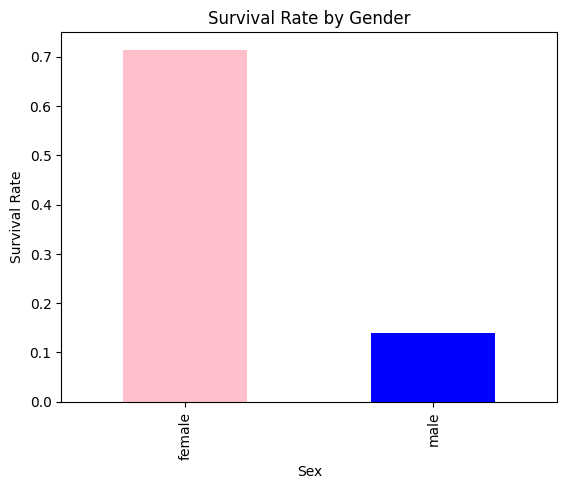

In [8]:
import matplotlib.pyplot as plt
df.groupby('Sex')['Survived'].mean().plot(kind='bar',color=['pink','blue'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

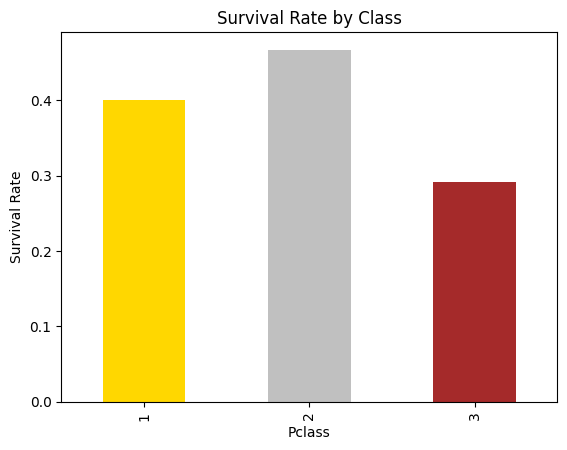

In [9]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar',color=['gold','silver','brown'])
plt.title('Survival Rate by Class')
plt.ylabel('Survival Rate')
plt.show()

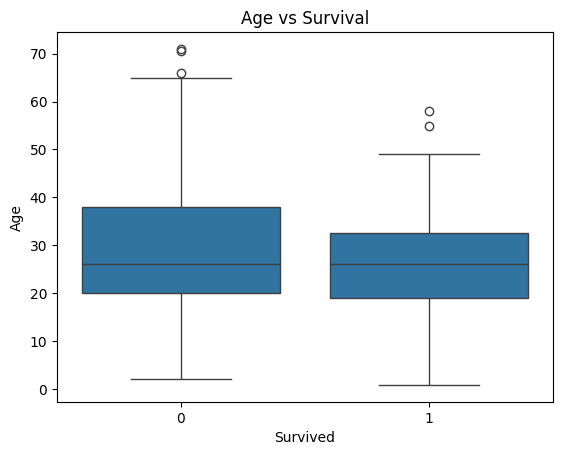

In [10]:
import seaborn as sns
sns.boxplot(x='Survived',y='Age',data=df)
plt.title('Age vs Survival')
plt.show()

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             30
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          125
Embarked         1
dtype: int64

In [12]:












df['Age'].fillna(df['Age'].median(),inplace=True)
df.drop('Cabin',axis=1,inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df.isnull().sum()

/tmp/ipykernel_755/4045534786.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
/tmp/ipykernel_755/4045534786.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
df['Sex']=df['Sex'].map({'male':0,'female':1})

X=df[['Pclass','Sex','Age']]
y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

model=LogisticRegression()
model.fit(X_train,y_train)

print("Model Ready ! Accuracy:",model.score(X_test,y_test))

Model Ready ! Accuracy: 0.78125


In [14]:
#NEW PASSENGER AND PREDICTION
new_passenger=pd.DataFrame({
    'Pclass':[3], #1,2,3 classes
    'Sex':[0], #0->male,1->female
    'Age':[25]
})

#prediction
result=model.predict(new_passenger)
print("Survived" if result[0]==1 else "Did not Survived!!")

Did not Survived!!


In [15]:
new_passenger2=pd.DataFrame({
    'Pclass':[1], #1,2,3 classes
    'Sex':[1], #0->male,1->female
    'Age':[25]
})

#prediction
result2=model.predict(new_passenger2)
print("Survived" if result2[0]==1 else "Did not Survived!!")

Survived


In [16]:
test=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
test.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
test['Age'].fillna(test['Age'].median(),inplace=True)
test['Sex']=test['Sex'].map({'male':0,'female':1})

X_test=test[['Pclass','Sex','Age']]
predictions=model.predict(X_test)

print(predictions[:10])

[0 1 1 1 0 0 0 0 1 1]


/tmp/ipykernel_755/4217655110.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Age'].fillna(test['Age'].median(),inplace=True)


In [18]:
submission=pd.DataFrame({
    'PassengerId':test['PassengerId'],
    'Survived':predictions
})

submission.to_csv('submission.csv',index=False)
print("CSV ready!")
submission.head()


CSV ready!


,PassengerId,Survived
0,1,0
1,2,1
2,3,1
3,4,1
4,5,0


In [19]:
submission=pd.DataFrame({
    'PassengerId':test['PassengerId'],
    'Survived':predictions.astype(int)
})

print(submission.shape)
print(submission.head())
submission.to_csv('submission.csv',index=False)
print("CSV ready!")


(891, 2)
   PassengerId  Survived
0            1         0
1            2         1
2            3         1
3            4         1
4            5         0
CSV ready!


In [20]:
test_official = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

test_official['Age'].fillna(test_official['Age'].median(), inplace=True)
test_official['Sex'] = test_official['Sex'].map({'male': 0, 'female': 1})

X_submit = test_official[['Pclass', 'Sex', 'Age']]
final_predictions = model.predict(X_submit)

submission = pd.DataFrame({
    'PassengerId': test_official['PassengerId'],
    'Survived': final_predictions.astype(int)
})

submission.to_csv('submission.csv', index=False)
print("Done!", submission.shape)

Done! (418, 2)


/tmp/ipykernel_755/3022021747.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_official['Age'].fillna(test_official['Age'].median(), inplace=True)


In [1]:
# from sklearn.ensemble import RandomForestClassifier
# modelr=RandomForestClassifier(n_estimators=100,random_state=42)
# modelr.fit(X_train,y_train)
# print("Accuracy:",modelr.score(X_test,y_test))

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Official Kaggle dataset
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

# Clean
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'].fillna('S', inplace=True)
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2}) #s:southampton , c:cherbourg , q:queenstown

# Features
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
model_rf.fit(X_train, y_train)
print("Accuracy:", model_rf.score(X_test, y_test))

Accuracy: 0.8100558659217877


/tmp/ipykernel_57/825192073.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_57/825192073.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [3]:
import pandas as pd
test_of=pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

test_of['Age'].fillna(test_of['Age'].median(),inplace=True)
test_of['Sex']=test_of['Sex'].map({'male':0,'female':1})
test_of['Fare'].fillna(test_of['Fare'].median(),inplace=True)
test_of['Embarked'].fillna('S',inplace=True)
test_of['Embarked']=test_of['Embarked'].map({'S':0,'C':1,'Q':2})

X_submit=test_of[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
predictions=model_rf.predict(X_submit)

submissionr=pd.DataFrame({
    'PassengerId':test_of['PassengerId'],
    'Survived':predictions.astype(int)
})

submissionr.to_csv('submissionn.csv',index=False)
print("Done!",submissionr.shape)

Done! (418, 2)


/tmp/ipykernel_57/2661850396.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_of['Age'].fillna(test_of['Age'].median(),inplace=True)
/tmp/ipykernel_57/2661850396.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [5]:
from xgboost import XGBClassifier

model_xgb=XGBClassifier(n_estimators=100,max_depth=3,learning_rate=0.1,random_state=42)
model_xgb.fit(X_train,y_train)
print("Accuracy:",model_xgb.score(X_test,y_test))

Accuracy: 0.8268156424581006


In [6]:
test_of=pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

test_of['Age'].fillna(test_of['Age'].median(),inplace=True)
test_of['Sex']=test_of['Sex'].map({'male':0,'female':1})
test_of['Fare'].fillna(test_of['Fare'].median(),inplace=True)
test_of['Embarked'].fillna('S',inplace=True)
test_of['Embarked']=test_of['Embarked'].map({'S':0,'C':1,'Q':2})

X_submit=test_of[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
predictions=model_xgb.predict(X_submit)

submissionx=pd.DataFrame({
    'PassengerId':test_of['PassengerId'],
    'Survived':predictions.astype(int)
})

submissionx.to_csv('submissionx.csv',index=False)
print("Done!",submissionx.shape)

Done! (418, 2)


/tmp/ipykernel_57/3535088435.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_of['Age'].fillna(test_of['Age'].median(),inplace=True)
/tmp/ipykernel_57/3535088435.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)